# Decode Stim1 for all good models

See if you can decode stim 1 identity during the delay period and during stim2

We can try this first:
- Train SVM decoder using only correct trials (firing rates). I would maybe use average firing rates from the first half of the delay period here. We can play around with the time window here.
- Next test the decoder on correct trials (generate another set of correct trials). (Use 2nd half of delay, and stim2)
- Test the decoder on incorrect trials (again use the second half of the delay window, and stim2).

We would expect for the decoder to have good perf when tested on correct trials and poor perf on incorrect trials.

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *

2025-06-02 11:08:59.028036: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-02 11:08:59.036756: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-02 11:08:59.046290: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-02 11:08:59.049070: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-02 11:08:59.057027: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# import SVM
from sklearn import svm
from sklearn.metrics import confusion_matrix

## Get good models

In [3]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [4]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

In [5]:
# get list of models with performance btwn 95-100%

good_models = []
for model_name in model_dirs:
    # get model directory
    model_dir = os.path.join(all_models_dir, model_name)
    
    _, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num)
    if np.mean(trial_perfs) > 0.95:
        good_models.append(model_name)
        print(f'{model_name} has performance {np.mean(trial_perfs)}, good model # {len(good_models)}')

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818 has performance 0.973, good model # 1
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727 has performance 0.958, good model # 2
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328 has performance 0.988, good model # 3
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_010848 has performance 0.991, good model # 4
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_140926 has performance 0.991, good model # 5
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_193816 has performance 0.973, good model # 6
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_040845 has performance 0.979, good model # 7
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_183907 has performance 0.959, good model # 8
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_200219 has performance 0.995, good model # 9
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_120653 has performance 0.982, good model # 10
Task_xor_N_200_Taus_4.0_25.0_

## Loop thru good models and do decoding

In [10]:
import concurrent.futures
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import svm

def decode_model(model_name):
    print(f'Starting model: {model_name}')
    
    # Load data (your existing code)
    _, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                           load_LFP=False, load_spikes=False, load_rates=True)
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=condn_num)
    times_ms, _, _ = ld.get_times_dict('ds', condn_phrase, condn_num, model_name)
    
    inout_labels = trial_labels[:,0] * trial_labels[:,1] # +1 for match, -1 for mismatch

    n_iter = 100
    n_cv = 10

    # train decoder

    acc_corr_delay2 = np.zeros(n_iter)
    acc_corr_delay2_null = np.zeros(n_iter)
    acc_incorr_delay2 = np.zeros(n_iter)
    acc_incorr_delay2_null = np.zeros(n_iter)
    acc_corr_stim2 = np.zeros(n_iter)
    acc_corr_stim2_null = np.zeros(n_iter)
    acc_incorr_stim2 = np.zeros(n_iter)
    acc_incorr_stim2_null = np.zeros(n_iter)
    
    acc_corr_stim2_match = np.zeros(n_iter)
    acc_corr_stim2_match_null = np.zeros(n_iter)
    acc_corr_stim2_mismatch = np.zeros(n_iter)
    acc_corr_stim2_mismatch_null = np.zeros(n_iter)
    acc_incorr_stim2_match = np.zeros(n_iter)
    acc_incorr_stim2_match_null = np.zeros(n_iter)
    acc_incorr_stim2_mismatch = np.zeros(n_iter)
    acc_incorr_stim2_mismatch_null = np.zeros(n_iter)

    correct_idx = np.where(trial_perfs == 1)[0]
    incorrect_idx = np.where(trial_perfs == 0)[0]

    corr_labels = trial_labels[correct_idx] # get labels for correct trials
    n_corr_pos = np.sum(corr_labels[:, 0] == 1)
    n_corr_neg = np.sum(corr_labels[:, 0] == -1)
    n_corr_sample = int(np.min([n_corr_pos, n_corr_neg]))  # balanced

    # balance incorrect trials too
    incorr_labels = trial_labels[incorrect_idx] # get labels for incorrect trials
    n_incorr_pos = np.sum(incorr_labels[:, 0] == 1)
    n_incorr_neg = np.sum(incorr_labels[:, 0] == -1)
    n_incorr_sample = int(np.min([n_incorr_pos, n_incorr_neg]))  # balanced
    if n_incorr_sample == 0:
        return None  # or return {}, then filter later


    # delay period segments
    delay_times_half1 = np.arange(times_ms['stim1_off'], times_ms['stim1_off'] + np.round(times_ms['delay']/2)).astype(int)
    delay_times_half2 = np.arange(times_ms['stim1_off'] + np.round(times_ms['delay']/2), times_ms['stim2_on']).astype(int)
    stim2_times = np.arange(times_ms['stim2_on'], times_ms['stim2_off']).astype(int)

    for i in range(n_iter):

        # Get pools of correct trials for each class
        pos_corr_pool = correct_idx[trial_labels[correct_idx, 0] == 1]
        neg_corr_pool = correct_idx[trial_labels[correct_idx, 0] == -1]
        pos_incorr_pool = incorrect_idx[trial_labels[incorrect_idx, 0] == 1]
        neg_incorr_pool = incorrect_idx[trial_labels[incorrect_idx, 0] == -1]

        # Balanced sampling
        corr_sample_pos = np.random.choice(pos_corr_pool, n_corr_sample, replace=True)
        corr_sample_neg = np.random.choice(neg_corr_pool, n_corr_sample, replace=True)
        corr_sample = np.concatenate((corr_sample_pos, corr_sample_neg))
        incorr_sample_pos = np.random.choice(pos_incorr_pool, n_incorr_sample, replace=True)
        incorr_sample_neg = np.random.choice(neg_incorr_pool, n_incorr_sample, replace=True)
        incorr_sample = np.concatenate((incorr_sample_pos, incorr_sample_neg))

        n_splits = 2
        n_test = int(np.floor(len(corr_sample) / n_splits))
        n_train = len(corr_sample) - n_test

        for j in range(n_cv):
            sample_indices = np.arange(len(corr_sample))
            test_indices = np.random.choice(sample_indices, n_test, replace=False)
            train_indices = np.setdiff1d(sample_indices, test_indices)

            test_idx = corr_sample[test_indices]
            train_idx = corr_sample[train_indices]

            # get labels for test and train trials
            train_labels = trial_labels[train_idx,0]
            test_labels = trial_labels[test_idx,0]
            test_matchmismatch = inout_labels[test_idx] # +1 match, -1 mismatch
            incorr_matchmismatch = inout_labels[incorr_sample]

            # get data for test and train trials  
            train_data = np.mean(rates_data[delay_times_half1,:,:], axis=0) # train on first half delay of one set 
            train_data = train_data[:, train_idx].T # train on first half delay of one set
            test_data_delay2 = np.mean(rates_data[delay_times_half2,:,:], axis=0) # test on second half delay 
            test_data_stim2 = np.mean(rates_data[stim2_times,:,:], axis=0) # test on stim2 period

            # fit SVM to training data
            clf = svm.SVC(kernel='linear', C=1.0)
            clf.fit(train_data, train_labels)
            clf_null = svm.SVC(kernel='linear', C=1.0) # null w shuffled labels
            train_labels_null = np.random.permutation(train_labels) # shuffle labels
            clf_null.fit(train_data, train_labels_null)

            # predict on test data, from correct delay half2
            test_data_corr = test_data_delay2[:, test_idx].T # test on second half delay of other set of corrects
            pred_labels_corr2 = clf.predict(test_data_corr)
            pred_labels_corr2_null = clf_null.predict(test_data_corr)
            acc_corr_delay2[i] += np.mean(pred_labels_corr2 == test_labels)
            acc_corr_delay2_null[i] += np.mean(pred_labels_corr2_null == test_labels)
    
            # predict on test data, from incorrect delay half2
            test_data_incorr = test_data_delay2[:, incorr_sample].T # test on second half delay of incorrects
            pred_labels_incorr2 = clf.predict(test_data_incorr)
            pred_labels_incorr2_null = clf_null.predict(test_data_incorr)
            acc_incorr_delay2[i] += np.mean(pred_labels_incorr2 == trial_labels[incorr_sample,0])
            acc_incorr_delay2_null[i] += np.mean(pred_labels_incorr2_null == trial_labels[incorr_sample,0])

            # predict on test data, from correct stim2
            test_data_corr = test_data_stim2[:, test_idx].T # test on stim2 period of other set of corrects
            pred_labels_corr2 = clf.predict(test_data_corr)
            pred_labels_corr2_null = clf_null.predict(test_data_corr)
            acc_corr_stim2[i] += np.mean(pred_labels_corr2 == test_labels)
            acc_corr_stim2_null[i] += np.mean(pred_labels_corr2_null == test_labels)
            acc_corr_stim2_match[i] += np.mean(pred_labels_corr2[test_matchmismatch == 1] == test_labels[test_matchmismatch == 1])
            acc_corr_stim2_match_null[i] += np.mean(pred_labels_corr2_null[test_matchmismatch == 1] == test_labels[test_matchmismatch == 1])
            acc_corr_stim2_mismatch[i] += np.mean(pred_labels_corr2[test_matchmismatch == -1] == test_labels[test_matchmismatch == -1])
            acc_corr_stim2_mismatch_null[i] += np.mean(pred_labels_corr2_null[test_matchmismatch == -1] == test_labels[test_matchmismatch == -1])
    
            # predict on test data, from incorrect stim2
            test_data_incorr = test_data_stim2[:, incorr_sample].T # test on stim2 period of incorrects
            pred_labels_incorr2 = clf.predict(test_data_incorr)
            pred_labels_incorr2_null = clf_null.predict(test_data_incorr)
            acc_incorr_stim2[i] += np.mean(pred_labels_incorr2 == trial_labels[incorr_sample,0])
            acc_incorr_stim2_null[i] += np.mean(pred_labels_incorr2_null == trial_labels[incorr_sample,0])
            acc_incorr_stim2_match[i] += np.mean(pred_labels_incorr2[incorr_matchmismatch == 1] == trial_labels[incorr_sample,0][incorr_matchmismatch == 1])
            acc_incorr_stim2_match_null[i] += np.mean(pred_labels_incorr2_null[incorr_matchmismatch == 1] == trial_labels[incorr_sample,0][incorr_matchmismatch == 1])
            acc_incorr_stim2_mismatch[i] += np.mean(pred_labels_incorr2[incorr_matchmismatch == -1] == trial_labels[incorr_sample,0][incorr_matchmismatch == -1])
            acc_incorr_stim2_mismatch_null[i] += np.mean(pred_labels_incorr2_null[incorr_matchmismatch == -1] == trial_labels[incorr_sample,0][incorr_matchmismatch == -1])

        # divide by n_cv
        acc_corr_delay2[i] /= n_cv
        acc_corr_delay2_null[i] /= n_cv
        acc_incorr_delay2[i] /= n_cv
        acc_incorr_delay2_null[i] /= n_cv
        acc_corr_stim2[i] /= n_cv
        acc_corr_stim2_null[i] /= n_cv
        acc_incorr_stim2[i] /= n_cv
        acc_incorr_stim2_null[i] /= n_cv
        acc_corr_stim2_match[i] /= n_cv
        acc_corr_stim2_match_null[i] /= n_cv
        acc_corr_stim2_mismatch[i] /= n_cv
        acc_corr_stim2_mismatch_null[i] /= n_cv
        acc_incorr_stim2_match[i] /= n_cv
        acc_incorr_stim2_match_null[i] /= n_cv
        acc_incorr_stim2_mismatch[i] /= n_cv
        acc_incorr_stim2_mismatch_null[i] /= n_cv
        
    return {
        'model_name': model_name,
        'acc_corr_delay2': acc_corr_delay2,
        'acc_incorr_delay2': acc_incorr_delay2,
        'acc_corr_delay2_null': acc_corr_delay2_null,
        'acc_incorr_delay2_null': acc_incorr_delay2_null,
        'acc_corr_stim2': acc_corr_stim2,
        'acc_incorr_stim2': acc_incorr_stim2,
        'acc_corr_stim2_null': acc_corr_stim2_null,
        'acc_incorr_stim2_null': acc_incorr_stim2_null,
        'acc_corr_stim2_match': acc_corr_stim2_match,
        'acc_corr_stim2_match_null': acc_corr_stim2_match_null,
        'acc_corr_stim2_mismatch': acc_corr_stim2_mismatch,
        'acc_corr_stim2_mismatch_null': acc_corr_stim2_mismatch_null,
        'acc_incorr_stim2_match': acc_incorr_stim2_match,
        'acc_incorr_stim2_match_null': acc_incorr_stim2_match_null,
        'acc_incorr_stim2_mismatch': acc_incorr_stim2_mismatch,
        'acc_incorr_stim2_mismatch_null': acc_incorr_stim2_mismatch_null
    }

# Use ProcessPoolExecutor to parallelize across models
with concurrent.futures.ProcessPoolExecutor() as executor:
    results = list(executor.map(decode_model, good_models))

results = [r for r in results if r is not None]  # Filter out None results

# Combine and save
decoding_results_df = pd.DataFrame(results)
decoding_results_df.to_pickle(f'results_data/decode_stim1_results_good_models_{condn_phrase}{condn_num}.pkl')

Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_010848Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727
Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_140926Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_193816

Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_040845Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_183907Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_120653Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_200219
Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_000755
Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212641Starting model: Task_xor_N_200_Ta

/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/nuttidalab/miniconda3/envs/rnn_test/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nuttidalab/miniconda3/envs/rnn_

In [11]:
decoding_results_df

,model_name,acc_corr_delay2,acc_incorr_delay2,acc_corr_delay2_null,acc_incorr_delay2_null,acc_corr_stim2,acc_incorr_stim2,acc_corr_stim2_null,acc_incorr_stim2_null,acc_corr_stim2_match,acc_corr_stim2_match_null,acc_corr_stim2_mismatch,acc_corr_stim2_mismatch_null,acc_incorr_stim2_match,acc_incorr_stim2_match_null,acc_incorr_stim2_mismatch,acc_incorr_stim2_mismatch_null
0,Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.5035343035343036, 0.477962577962578, 0.5382...","[0.61875, 0.43125, 0.51875, 0.6375, 0.6, 0.468...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.9375, 0.9375, 0.9375, 0.9375, 0.9875, 0.937...","[0.46673596673596673, 0.45280665280665283, 0.5...","[0.5, 0.4875, 0.45625, 0.49375, 0.65, 0.475, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.35254391331938273, 0.33975715537512113, 0.6...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.5812507152820497, 0.5587987626803635, 0.421...","[0.5, 0.5, 0.5, 0.5, nan, 0.5, 0.0, 1.0, nan, ...","[0.4, 0.6, 0.45, 0.55, nan, 0.6, 0.5, 0.7, nan...","[1.0, 1.0, 1.0, 1.0, 0.9875, 1.0, 1.0, 1.0, 1....","[0.5142857142857143, 0.47142857142857136, 0.45..."
1,Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.4982795698924731, 0.44537634408602156, 0.48...","[0.5071428571428572, 0.45, 0.36428571428571427...","[0.9991397849462367, 1.0, 0.9982795698924731, ...","[1.0, 1.0, 1.0, 0.9928571428571429, 1.0, 1.0, ...","[0.4666666666666667, 0.4533333333333333, 0.521...","[0.5857142857142856, 0.3928571428571429, 0.414...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.40063181989597874, 0.5713033343528503, 0.63...","[0.9981962096531085, 1.0, 0.9963581376343008, ...","[0.5431368754673899, 0.34444645701945587, 0.40...","[1.0, 1.0, 1.0, nan, nan, 1.0, 1.0, 1.0, nan, ...","[0.4, 0.65, 0.6, nan, nan, 0.8, 0.5, 0.4, nan,...","[1.0, 1.0, 1.0, 0.9928571428571429, 1.0, 1.0, ...","[0.5999999999999999, 0.35, 0.38333333333333336..."
2,Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.5260692464358453, 0.45661914460285136, 0.47...","[0.6666666666666667, 0.4666666666666667, 0.333...","[0.9989816700610996, 0.9991853360488798, 1.0, ...","[0.8, 0.85, 0.6666666666666667, 0.85, 0.85, 0....","[0.5293279022403258, 0.4415478615071283, 0.461...","[0.5333333333333333, 0.3833333333333333, 0.433...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.46988870089212514, 0.43900962908123714, 0.5...","[0.9979595500090414, 0.9984227545434331, 1.0, ...","[0.5915322847148292, 0.4428289665851091, 0.399...","[nan, nan, nan, nan, nan, nan, 1.0, nan, nan, ...","[nan, nan, nan, nan, nan, nan, 0.5, nan, nan, ...","[0.8, 0.85, 0.6666666666666667, 0.85, 0.85, 0....","[0.5333333333333333, 0.3833333333333333, 0.433..."
3,Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.5, 0.43475609756097555, 0.518089430894309, ...","[0.65, 0.3, 0.6, 0.5, 0.5, 0.45, 0.75, 0.35, 0...","[0.997560975609756, 0.9985772357723578, 0.9985...","[1.0, 1.0, 1.0, 1.0, 0.7, 1.0, 0.75, 0.55, 0.6...","[0.509959349593496, 0.47865853658536583, 0.477...","[0.4, 0.45, 0.5, 0.4, 0.65, 0.7, 0.4, 0.45, 0....","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.38183197438045846, 0.4138065807187975, 0.42...","[0.9952448051055208, 0.9972568445543446, 0.997...","[0.6302571962715261, 0.5464404109761356, 0.540...","[1.0, 1.0, 1.0, 1.0, 0.7, 1.0, 0.75, 0.55, 0.6...","[0.4, 0.45, 0.5, 0.4, 0.65, 0.7, 0.4, 0.45, 0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
4,Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0

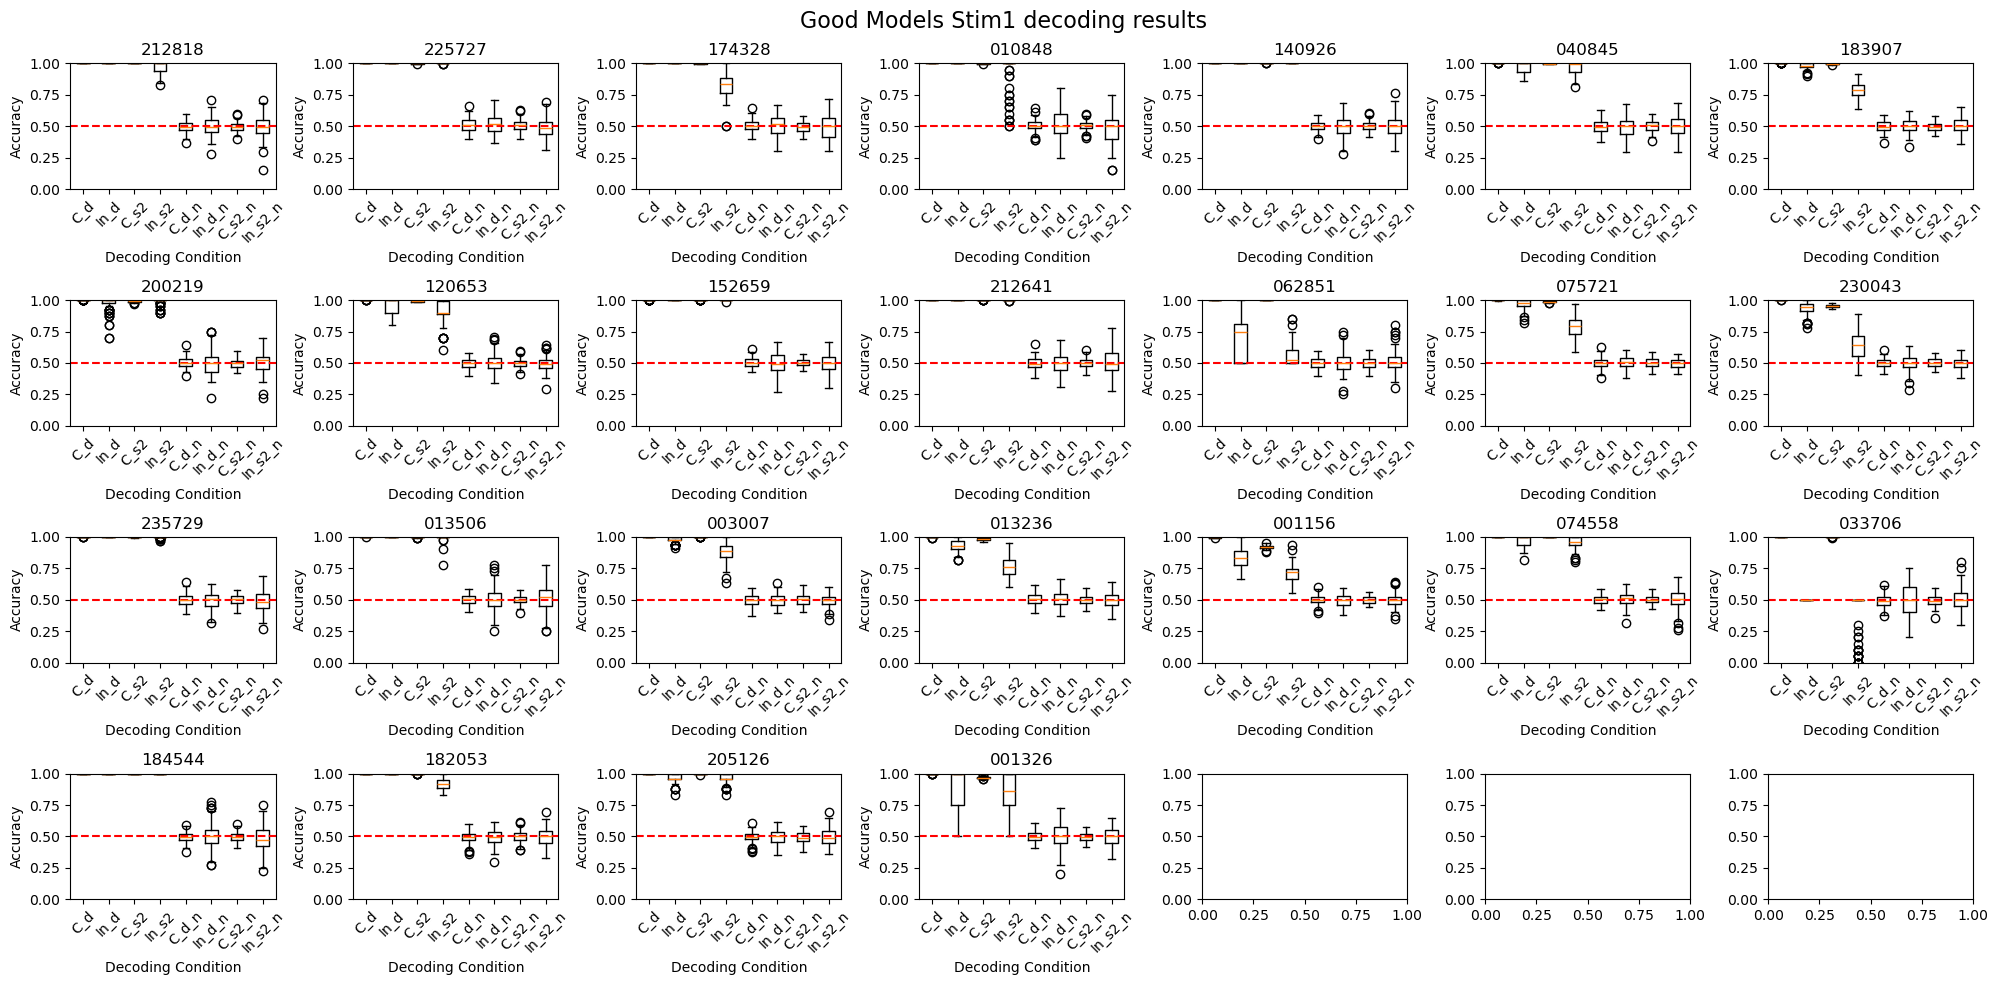

In [12]:
# plot them as boxplots

fig, axs = plt.subplots(4, 7, figsize=(20, 10))
fig.suptitle(f'Good Models Stim1 decoding results', fontsize=16)
axs = axs.flatten()

for i_model, model_data in decoding_results_df.iterrows():
    model_name = model_data['model_name'][-6:]
    acc_corr_delay2 = model_data['acc_corr_delay2']
    acc_incorr_delay2 = model_data['acc_incorr_delay2']
    acc_corr_delay2_null = model_data['acc_corr_delay2_null']
    acc_incorr_delay2_null = model_data['acc_incorr_delay2_null']
    acc_corr_stim2 = model_data['acc_corr_stim2']
    acc_incorr_stim2 = model_data['acc_incorr_stim2']
    acc_corr_stim2_null = model_data['acc_corr_stim2_null']
    acc_incorr_stim2_null = model_data['acc_incorr_stim2_null']

    # plot 
    axs[i_model].boxplot([acc_corr_delay2, acc_incorr_delay2, acc_corr_stim2, acc_incorr_stim2, acc_corr_delay2_null, acc_incorr_delay2_null, acc_corr_stim2_null, acc_incorr_stim2_null])
    axs[i_model].axhline(y=0.5, color='r', linestyle='--')
    axs[i_model].set_title(model_name)
    axs[i_model].set_ylabel('Accuracy')
    axs[i_model].set_ylim(0, 1)
    axs[i_model].set_xticklabels(['C_d', 'In_d', 'C_s2', 'In_s2', 'C_d_n', 'In_d_n', 'C_s2_n', 'In_s2_n'], rotation=45)
    # axs[i_model].legend()
    axs[i_model].set_xlabel('Decoding Condition')
    axs[i_model].set_title(model_name)

plt.tight_layout()
plt.show()
    

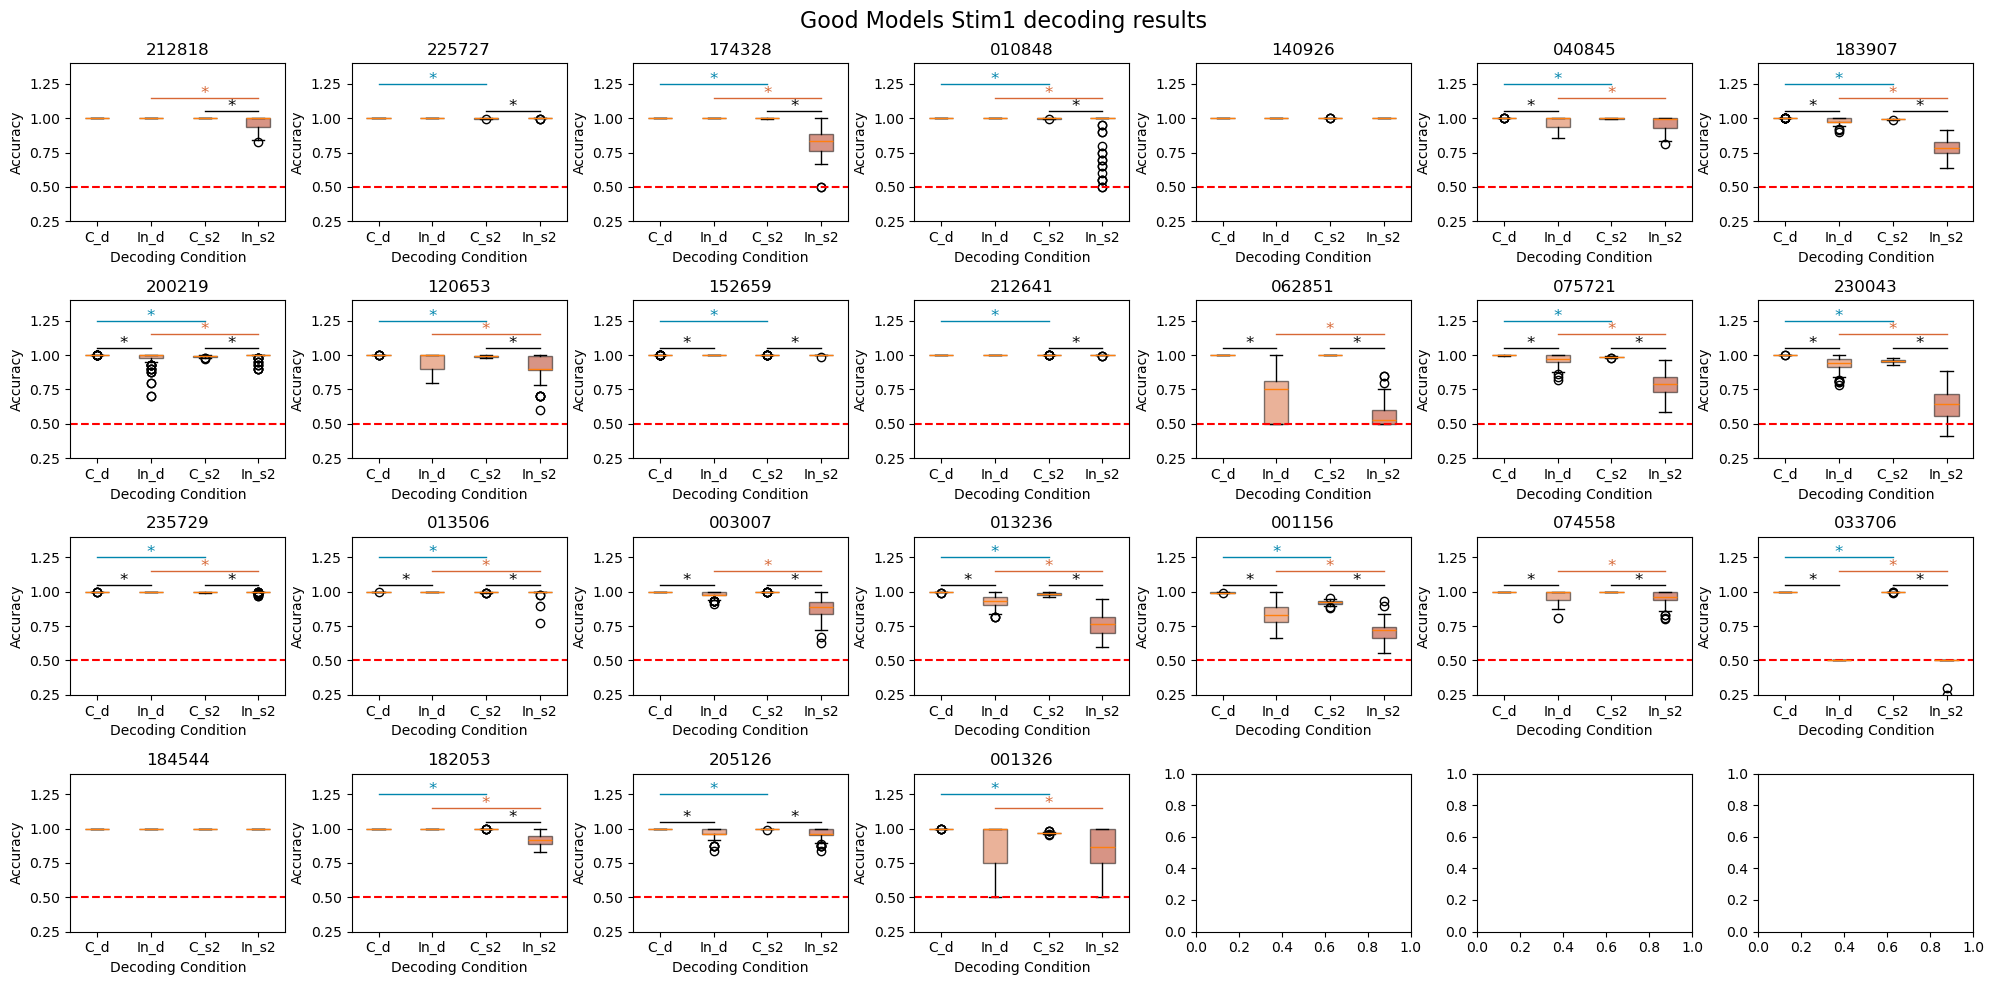

In [13]:
# plot them as boxplots

fig, axs = plt.subplots(4, 7, figsize=(20, 10))
fig.suptitle(f'Good Models Stim1 decoding results', fontsize=16)
axs = axs.flatten()

colors = ['#0085AD','#D76735','#222F5B','#B12A0C']

for i_model, model_data in decoding_results_df.iterrows():
    model_name = model_data['model_name'][-6:]
    acc_corr_delay2 = model_data['acc_corr_delay2']
    acc_incorr_delay2 = model_data['acc_incorr_delay2']
    acc_corr_delay2_null = model_data['acc_corr_delay2_null']
    acc_incorr_delay2_null = model_data['acc_incorr_delay2_null']
    acc_corr_stim2 = model_data['acc_corr_stim2']
    acc_incorr_stim2 = model_data['acc_incorr_stim2']
    acc_corr_stim2_null = model_data['acc_corr_stim2_null']
    acc_incorr_stim2_null = model_data['acc_incorr_stim2_null']

    # do stats
    corr_time_p = scipy.stats.mannwhitneyu(acc_corr_delay2, acc_corr_stim2)[1]
    incorr_time_p = scipy.stats.mannwhitneyu(acc_incorr_delay2, acc_incorr_stim2)[1]
    delay_p = scipy.stats.mannwhitneyu(acc_corr_delay2, acc_incorr_delay2)[1]
    stim2_p = scipy.stats.mannwhitneyu(acc_corr_stim2, acc_incorr_stim2)[1]

    # plot 
    bp = axs[i_model].boxplot([acc_corr_delay2, acc_incorr_delay2, acc_corr_stim2, acc_incorr_stim2], patch_artist=True)
    axs[i_model].axhline(y=0.5, color='r', linestyle='--')
    axs[i_model].set_title(model_name)
    axs[i_model].set_ylabel('Accuracy')
    axs[i_model].set_ylim(0.25, 1.4)
    axs[i_model].set_xticklabels(['C_d', 'In_d', 'C_s2', 'In_s2'])
    for k, box in enumerate(bp['boxes']):
        box.set_facecolor(colors[k])  # Set the face color of the box
        box.set_edgecolor('black')  # Optionally set edge color
        box.set_alpha(0.5)  # Set transparency (optional)
    
    # Add significance stars and p-values
    if corr_time_p < 0.05:
        axs[i_model].text(2, 1.25, '*', fontsize=12, color=colors[0], ha='center')
        # axs[i_model].text(2, 1.2, f'p={corr_time_p:.3f}', fontsize=10, color=colors[0], ha='center')
        axs[i_model].plot([1,3], [1.25, 1.25], color=colors[0], lw=1)
    if incorr_time_p < 0.05:
        axs[i_model].text(3, 1.15, '*', fontsize=12, color=colors[1], ha='center')
        # axs[i_model].text(3, 1.2, f'p={incorr_time_p:.3f}', fontsize=10, color=colors[1], ha='center')
        axs[i_model].plot([2,4], [1.15, 1.15], color=colors[1], lw=1)
    if delay_p < 0.05:
        axs[i_model].text(1.5, 1.05, '*', fontsize=12, color='black', ha='center')
        # axs[i_model].text(1.5, 1.1, f'p={delay_p:.3f}', fontsize=10, color='black', ha='center')
        axs[i_model].plot([1,2], [1.05, 1.05], color='black', lw=1)
    if stim2_p < 0.05:
        axs[i_model].text(3.5, 1.05, '*', fontsize=12, color='black', ha='center')
        # axs[i_model].text(3.5, 1.1, f'p={stim2_p:.3f}', fontsize=10, color='black', ha='center')
        axs[i_model].plot([3,4], [1.05, 1.05], color='black', lw=1)

    axs[i_model].set_xlabel('Decoding Condition')
    axs[i_model].set_title(model_name)

plt.tight_layout()
plt.show()
    

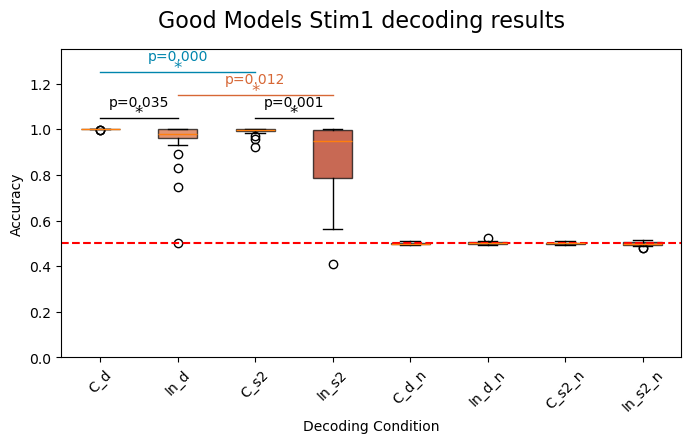

In [14]:
# now take mean and aggregate across models and do boxplot

corr_delay2_means = np.zeros(len(decoding_results_df))
incorr_delay2_means = np.zeros(len(decoding_results_df))
corr_delay2_null_means = np.zeros(len(decoding_results_df))
incorr_delay2_null_means = np.zeros(len(decoding_results_df))
corr_stim2_means = np.zeros(len(decoding_results_df))
incorr_stim2_means = np.zeros(len(decoding_results_df))
corr_stim2_null_means = np.zeros(len(decoding_results_df))
incorr_stim2_null_means = np.zeros(len(decoding_results_df))

for i_model, model_data in decoding_results_df.iterrows():
    corr_delay2_means[i_model] = np.mean(model_data['acc_corr_delay2'])
    incorr_delay2_means[i_model] = np.mean(model_data['acc_incorr_delay2'])
    corr_delay2_null_means[i_model] = np.mean(model_data['acc_corr_delay2_null'])
    incorr_delay2_null_means[i_model] = np.mean(model_data['acc_incorr_delay2_null'])
    corr_stim2_means[i_model] = np.mean(model_data['acc_corr_stim2'])
    incorr_stim2_means[i_model] = np.mean(model_data['acc_incorr_stim2'])
    corr_stim2_null_means[i_model] = np.mean(model_data['acc_corr_stim2_null'])
    incorr_stim2_null_means[i_model] = np.mean(model_data['acc_incorr_stim2_null'])

# do stats
corr_delay2_p = scipy.stats.mannwhitneyu(corr_delay2_means, corr_stim2_means)[1]
incorr_delay2_p = scipy.stats.mannwhitneyu(incorr_delay2_means, incorr_stim2_means)[1]
delay_p = scipy.stats.mannwhitneyu(corr_delay2_means, incorr_delay2_means)[1]
stim2_p = scipy.stats.mannwhitneyu(corr_stim2_means, incorr_stim2_means)[1]

# plot
fig, axs = plt.subplots(1, 1, figsize=(8, 4))
fig.suptitle(f'Good Models Stim1 decoding results', fontsize=16)
bp = axs.boxplot([corr_delay2_means, incorr_delay2_means, corr_stim2_means, incorr_stim2_means, corr_delay2_null_means, incorr_delay2_null_means, corr_stim2_null_means, incorr_stim2_null_means], 
patch_artist=True)
for k, box in enumerate(bp['boxes']):
    box.set_facecolor(colors[k%4])  # Set the face color of the box
    box.set_edgecolor('black')  # Optionally set edge color
    box.set_alpha(0.7)  # Set transparency (optional)

# Add significance stars and p-values
if corr_delay2_p < 0.05:
    axs.text(2, 1.25, '*', fontsize=12, color=colors[0], ha='center')
    axs.text(2, 1.3, f'p={corr_delay2_p:.3f}', fontsize=10, color=colors[0], ha='center')
    axs.plot([1,3], [1.25, 1.25], color=colors[0], lw=1)
if incorr_delay2_p < 0.05:
    axs.text(3, 1.15, '*', fontsize=12, color=colors[1], ha='center')
    axs.text(3, 1.2, f'p={incorr_delay2_p:.3f}', fontsize=10, color=colors[1], ha='center')
    axs.plot([2,4], [1.15, 1.15], color=colors[1], lw=1)
if delay_p < 0.05:
    axs.text(1.5, 1.05, '*', fontsize=12, color='black', ha='center')
    axs.text(1.5, 1.1, f'p={delay_p:.3f}', fontsize=10, color='black', ha='center')
    axs.plot([1,2], [1.05, 1.05], color='black', lw=1)
if stim2_p < 0.05:
    axs.text(3.5, 1.05, '*', fontsize=12, color='black', ha='center')
    axs.text(3.5, 1.1, f'p={stim2_p:.3f}', fontsize=10, color='black', ha='center')
    axs.plot([3,4], [1.05, 1.05], color='black', lw=1)
axs.axhline(y=0.5, color='r', linestyle='--')
axs.set_ylabel('Accuracy')
axs.set_ylim(0, 1.35)
axs.set_xticks([1, 2, 3, 4, 5, 6, 7, 8])
axs.set_xticklabels(['C_d', 'In_d', 'C_s2', 'In_s2', 'C_d_n', 'In_d_n', 'C_s2_n', 'In_s2_n'], rotation=45)
axs.set_xlabel('Decoding Condition');

## Split up decoding of match vs mismatch

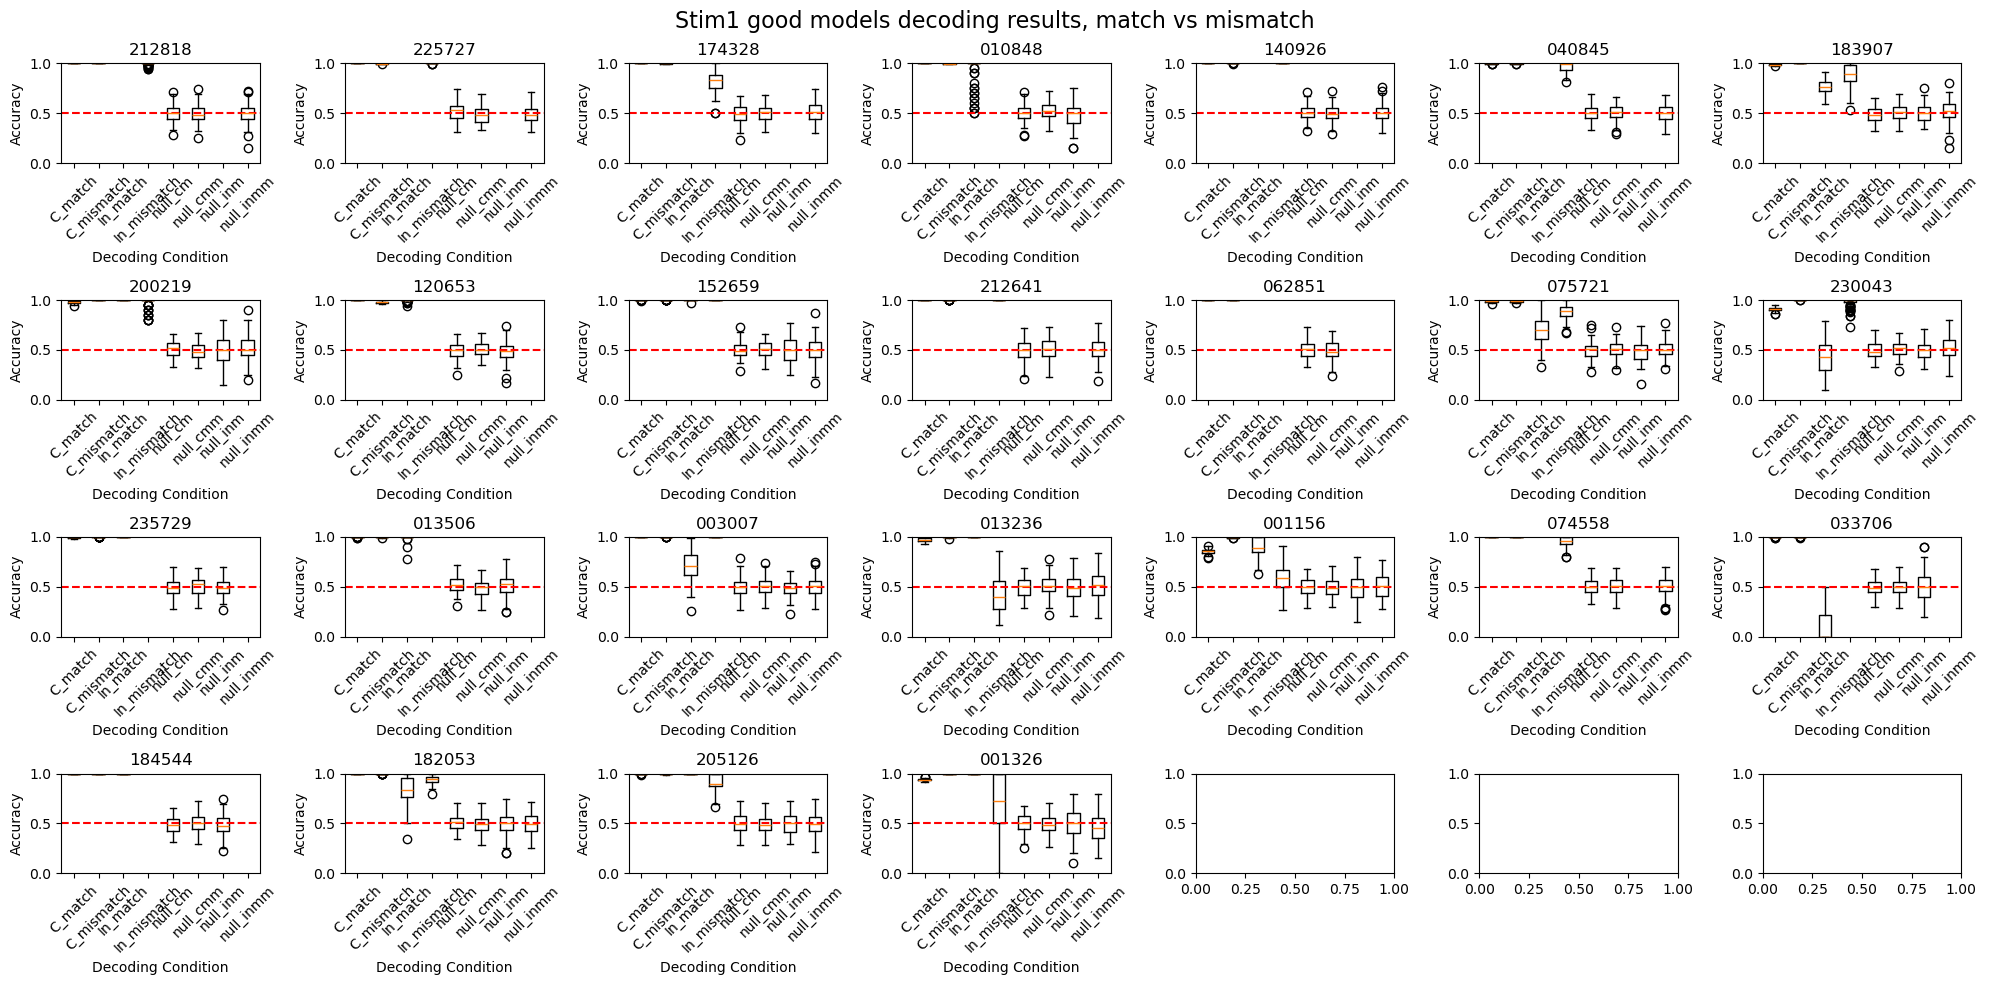

In [18]:
# now plot difference btwn match and mismatch accuracies

fig, axs = plt.subplots(4, 7, figsize=(20, 10))
fig.suptitle(f'Stim1 good models decoding results, match vs mismatch', fontsize=16)
axs = axs.flatten()

for i_model, model_data in decoding_results_df.iterrows():
    model_name = model_data['model_name'][-6:]
    acc_corr_stim2_match = model_data['acc_corr_stim2_match']
    acc_incorr_stim2_match = model_data['acc_incorr_stim2_match']
    acc_corr_stim2_match_null = model_data['acc_corr_stim2_match_null']
    acc_incorr_stim2_match_null = model_data['acc_incorr_stim2_match_null']
    acc_corr_stim2_mismatch = model_data['acc_corr_stim2_mismatch']
    acc_incorr_stim2_mismatch = model_data['acc_incorr_stim2_mismatch']
    acc_corr_stim2_mismatch_null = model_data['acc_corr_stim2_mismatch_null']
    acc_incorr_stim2_mismatch_null = model_data['acc_incorr_stim2_mismatch_null']

    # plot 
    axs[i_model].boxplot([acc_corr_stim2_match, acc_corr_stim2_mismatch, acc_incorr_stim2_match, acc_incorr_stim2_mismatch, 
                          acc_corr_stim2_match_null, acc_corr_stim2_mismatch_null, acc_incorr_stim2_match_null, acc_incorr_stim2_mismatch_null])
    axs[i_model].axhline(y=0.5, color='r', linestyle='--')
    axs[i_model].set_title(model_name)
    axs[i_model].set_ylabel('Accuracy')
    axs[i_model].set_ylim(0, 1)
    axs[i_model].set_xticklabels(['C_match', 'C_mismatch', 'In_match', 'In_mismatch', 'null_cm', 'null_cmm', 'null_inm', 'null_inmm'], rotation=45)
    # axs[i_model].legend()
    axs[i_model].set_xlabel('Decoding Condition')
    axs[i_model].set_title(model_name)

plt.tight_layout()
plt.show()
    

/tmp/ipykernel_1212853/2705382083.py:22: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  incorr_p = scipy.stats.mannwhitneyu(acc_incorr_stim2_match, acc_incorr_stim2_mismatch, nan_policy='omit')[1]
/tmp/ipykernel_1212853/2705382083.py:24: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  mismatch_p = scipy.stats.mannwhitneyu(acc_corr_stim2_mismatch, acc_incorr_stim2_mismatch, nan_policy='omit')[1]
/tmp/ipykernel_1212853/2705382083.py:22: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  incorr_p = scipy.stats.mannwhitneyu(acc_incorr_stim2_match, acc_incorr_stim2_mismatch, nan_policy='omit')[1]
/tmp/ipykernel_1212853/2705382083.py:23: Small

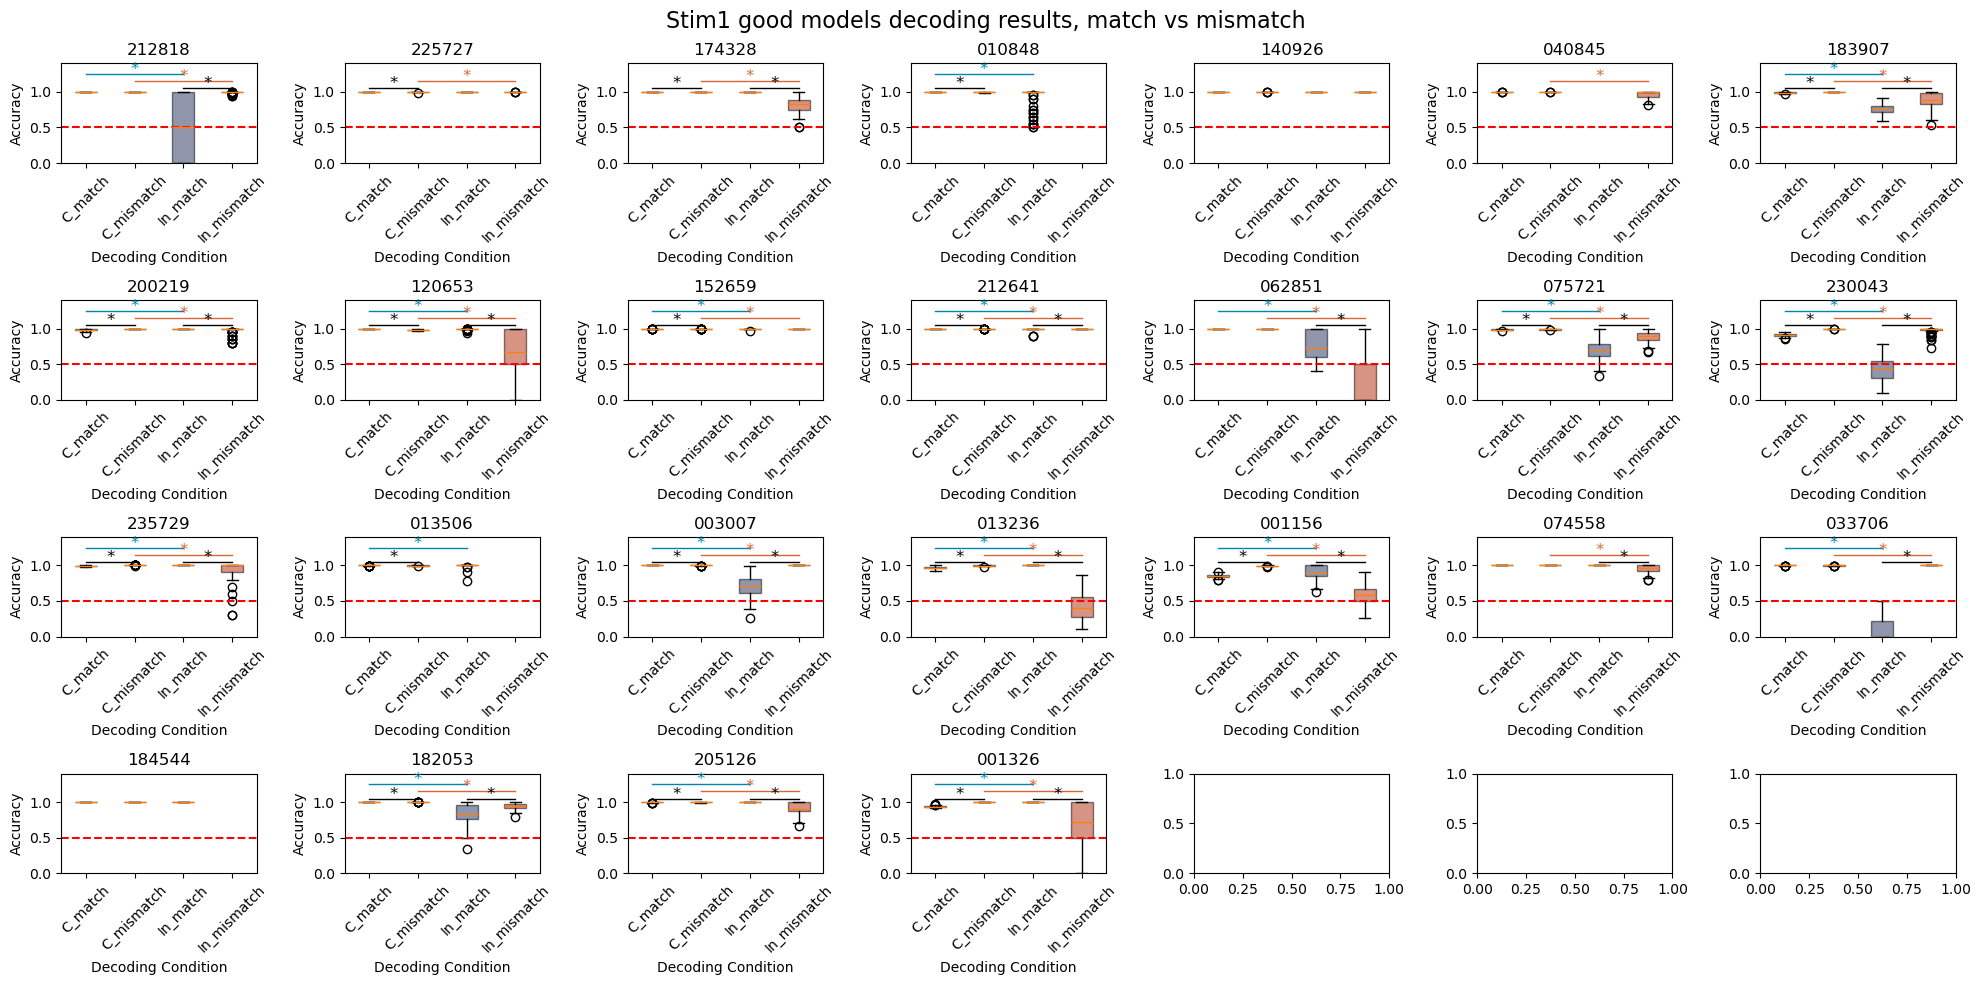

In [25]:
# plot them as boxplots

fig, axs = plt.subplots(4, 7, figsize=(20, 10))
fig.suptitle(f'Stim1 good models decoding results, match vs mismatch', fontsize=16)
axs = axs.flatten()

colors = ['#0085AD','#D76735','#222F5B','#B12A0C']

for i_model, model_data in decoding_results_df.iterrows():
    model_name = model_data['model_name'][-6:]
    acc_corr_stim2_match = model_data['acc_corr_stim2_match']
    acc_incorr_stim2_match = model_data['acc_incorr_stim2_match']
    acc_corr_stim2_match_null = model_data['acc_corr_stim2_match_null']
    acc_incorr_stim2_match_null = model_data['acc_incorr_stim2_match_null']
    acc_corr_stim2_mismatch = model_data['acc_corr_stim2_mismatch']
    acc_incorr_stim2_mismatch = model_data['acc_incorr_stim2_mismatch']
    acc_corr_stim2_mismatch_null = model_data['acc_corr_stim2_mismatch_null']
    acc_incorr_stim2_mismatch_null = model_data['acc_incorr_stim2_mismatch_null']

    # do stats
    corr_p = scipy.stats.mannwhitneyu(acc_corr_stim2_match, acc_corr_stim2_mismatch, nan_policy='omit')[1]
    incorr_p = scipy.stats.mannwhitneyu(acc_incorr_stim2_match, acc_incorr_stim2_mismatch, nan_policy='omit')[1]
    match_p = scipy.stats.mannwhitneyu(acc_corr_stim2_match, acc_incorr_stim2_match, nan_policy='omit')[1]
    mismatch_p = scipy.stats.mannwhitneyu(acc_corr_stim2_mismatch, acc_incorr_stim2_mismatch, nan_policy='omit')[1]

    # plot 
    bp = axs[i_model].boxplot([acc_corr_stim2_match, acc_corr_stim2_mismatch, 
                               acc_incorr_stim2_match[~np.isnan(acc_incorr_stim2_match)], acc_incorr_stim2_mismatch[~np.isnan(acc_incorr_stim2_mismatch)],], 
                              patch_artist=True)
    axs[i_model].axhline(y=0.5, color='r', linestyle='--')
    axs[i_model].set_title(model_name)
    axs[i_model].set_ylabel('Accuracy')
    axs[i_model].set_ylim(0, 1.4)
    axs[i_model].set_xticklabels(['C_match', 'C_mismatch', 'In_match', 'In_mismatch'], rotation=45)
    for k, box in enumerate(bp['boxes']):
        box.set_facecolor(colors[k])  # Set the face color of the box
        box.set_edgecolor('black')  # Optionally set edge color
        box.set_alpha(0.5)  # Set transparency (optional)
    
    # Add significance stars and p-values
    if match_p < 0.05:
        axs[i_model].text(2, 1.25, '*', fontsize=12, color=colors[0], ha='center')
        # axs[i_model].text(2, 1.2, f'p={corr_time_p:.3f}', fontsize=10, color=colors[0], ha='center')
        axs[i_model].plot([1,3], [1.25, 1.25], color=colors[0], lw=1)
    if mismatch_p < 0.05:
        axs[i_model].text(3, 1.15, '*', fontsize=12, color=colors[1], ha='center')
        # axs[i_model].text(3, 1.2, f'p={incorr_time_p:.3f}', fontsize=10, color=colors[1], ha='center')
        axs[i_model].plot([2,4], [1.15, 1.15], color=colors[1], lw=1)
    if corr_p < 0.05:
        axs[i_model].text(1.5, 1.05, '*', fontsize=12, color='black', ha='center')
        # axs[i_model].text(1.5, 1.1, f'p={delay_p:.3f}', fontsize=10, color='black', ha='center')
        axs[i_model].plot([1,2], [1.05, 1.05], color='black', lw=1)
    if incorr_p < 0.05:
        axs[i_model].text(3.5, 1.05, '*', fontsize=12, color='black', ha='center')
        # axs[i_model].text(3.5, 1.1, f'p={stim2_p:.3f}', fontsize=10, color='black', ha='center')
        axs[i_model].plot([3,4], [1.05, 1.05], color='black', lw=1)

    axs[i_model].set_xlabel('Decoding Condition')
    axs[i_model].set_title(model_name)

plt.tight_layout()
plt.show()
    

/tmp/ipykernel_1212853/1758298990.py:19: RuntimeWarning: Mean of empty slice
  acc_incorr_stim2_mismatch[i_model] = np.nanmean(model_data['acc_incorr_stim2_mismatch'])
/tmp/ipykernel_1212853/1758298990.py:21: RuntimeWarning: Mean of empty slice
  acc_incorr_stim2_mismatch_null[i_model] = np.nanmean(model_data['acc_incorr_stim2_mismatch_null'])
/tmp/ipykernel_1212853/1758298990.py:15: RuntimeWarning: Mean of empty slice
  acc_incorr_stim2_match[i_model] = np.nanmean(model_data['acc_incorr_stim2_match'])
/tmp/ipykernel_1212853/1758298990.py:17: RuntimeWarning: Mean of empty slice
  acc_incorr_stim2_match_null[i_model] = np.nanmean(model_data['acc_incorr_stim2_match_null'])


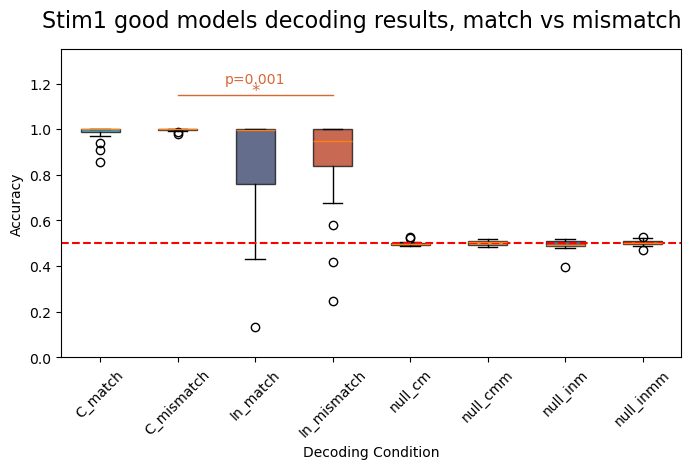

In [24]:
# now take mean and aggregate across models and do boxplot

acc_corr_stim2_match = np.zeros(len(decoding_results_df))
acc_incorr_stim2_match = np.zeros(len(decoding_results_df))
acc_corr_stim2_match_null = np.zeros(len(decoding_results_df))
acc_incorr_stim2_match_null = np.zeros(len(decoding_results_df))
acc_corr_stim2_mismatch = np.zeros(len(decoding_results_df))
acc_incorr_stim2_mismatch = np.zeros(len(decoding_results_df))
acc_corr_stim2_mismatch_null = np.zeros(len(decoding_results_df))
acc_incorr_stim2_mismatch_null = np.zeros(len(decoding_results_df))


for i_model, model_data in decoding_results_df.iterrows():
    acc_corr_stim2_match[i_model] = np.nanmean(model_data['acc_corr_stim2_match'])
    acc_incorr_stim2_match[i_model] = np.nanmean(model_data['acc_incorr_stim2_match'])
    acc_corr_stim2_match_null[i_model] = np.nanmean(model_data['acc_corr_stim2_match_null'])
    acc_incorr_stim2_match_null[i_model] = np.nanmean(model_data['acc_incorr_stim2_match_null'])
    acc_corr_stim2_mismatch[i_model] = np.nanmean(model_data['acc_corr_stim2_mismatch'])
    acc_incorr_stim2_mismatch[i_model] = np.nanmean(model_data['acc_incorr_stim2_mismatch'])
    acc_corr_stim2_mismatch_null[i_model] = np.nanmean(model_data['acc_corr_stim2_mismatch_null'])
    acc_incorr_stim2_mismatch_null[i_model] = np.nanmean(model_data['acc_incorr_stim2_mismatch_null'])
    

# do stats
corr_p = scipy.stats.mannwhitneyu(acc_corr_stim2_match, acc_corr_stim2_mismatch, nan_policy='omit')[1]
incorr_p = scipy.stats.mannwhitneyu(acc_incorr_stim2_match, acc_incorr_stim2_mismatch, nan_policy='omit')[1]
match_p = scipy.stats.mannwhitneyu(acc_corr_stim2_match, acc_incorr_stim2_match, nan_policy='omit')[1]
mismatch_p = scipy.stats.mannwhitneyu(acc_corr_stim2_mismatch, acc_incorr_stim2_mismatch, nan_policy='omit')[1]

# plot
fig, axs = plt.subplots(1, 1, figsize=(8, 4))
fig.suptitle(f'Stim1 good models decoding results, match vs mismatch', fontsize=16)
bp = axs.boxplot([acc_corr_stim2_match, acc_corr_stim2_mismatch, 
                  acc_incorr_stim2_match[~np.isnan(acc_incorr_stim2_match)], acc_incorr_stim2_mismatch[~np.isnan(acc_incorr_stim2_mismatch)], 
                          acc_corr_stim2_match_null, acc_corr_stim2_mismatch_null, 
                          acc_incorr_stim2_match_null[~np.isnan(acc_incorr_stim2_match_null)], acc_incorr_stim2_mismatch_null[~np.isnan(acc_incorr_stim2_mismatch_null)]], 
                 patch_artist=True)
for k, box in enumerate(bp['boxes']):
    box.set_facecolor(colors[k%4])  # Set the face color of the box
    box.set_edgecolor('black')  # Optionally set edge color
    box.set_alpha(0.7)  # Set transparency (optional)

# Add significance stars and p-values
if match_p < 0.05:
    axs.text(2, 1.25, '*', fontsize=12, color=colors[0], ha='center')
    axs.text(2, 1.3, f'p={match_p:.3f}', fontsize=10, color=colors[0], ha='center')
    axs.plot([1,3], [1.25, 1.25], color=colors[0], lw=1)
if mismatch_p < 0.05:
    axs.text(3, 1.15, '*', fontsize=12, color=colors[1], ha='center')
    axs.text(3, 1.2, f'p={mismatch_p:.3f}', fontsize=10, color=colors[1], ha='center')
    axs.plot([2,4], [1.15, 1.15], color=colors[1], lw=1)
if corr_p < 0.05:
    axs.text(1.5, 1.05, '*', fontsize=12, color='black', ha='center')
    axs.text(1.5, 1.1, f'p={corr_p:.3f}', fontsize=10, color='black', ha='center')
    axs.plot([1,2], [1.05, 1.05], color='black', lw=1)
if incorr_p < 0.05:
    axs.text(3.5, 1.05, '*', fontsize=12, color='black', ha='center')
    axs.text(3.5, 1.1, f'p={incorr_p:.3f}', fontsize=10, color='black', ha='center')
    axs.plot([3,4], [1.05, 1.05], color='black', lw=1)
axs.axhline(y=0.5, color='r', linestyle='--')
axs.set_ylabel('Accuracy')
axs.set_ylim(0, 1.35)
axs.set_xticks([1, 2, 3, 4, 5, 6, 7, 8])
axs.set_xticklabels(['C_match', 'C_mismatch', 'In_match', 'In_mismatch', 'null_cm', 'null_cmm', 'null_inm', 'null_inmm'], rotation=45)
axs.set_xlabel('Decoding Condition');

## Good vs bad

In [5]:
decoding_results_good = pd.read_pickle(f'results_data/decode_stim1_results_good_models_{condn_phrase}{condn_num}.pkl')
decoding_results_bad = pd.read_pickle(f'results_data/decode_stim1_results_bad_models_{condn_phrase}{condn_num}.pkl')

In [6]:
decoding_results_good.head()

,model_name,acc_corr_delay2,acc_incorr_delay2,acc_corr_delay2_null,acc_incorr_delay2_null,acc_corr_stim2,acc_incorr_stim2,acc_corr_stim2_null,acc_incorr_stim2_null,acc_corr_stim2_match,acc_corr_stim2_match_null,acc_corr_stim2_mismatch,acc_corr_stim2_mismatch_null,acc_incorr_stim2_match,acc_incorr_stim2_match_null,acc_incorr_stim2_mismatch,acc_incorr_stim2_mismatch_null
0,Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.5035343035343036, 0.477962577962578, 0.5382...","[0.61875, 0.43125, 0.51875, 0.6375, 0.6, 0.468...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.9375, 0.9375, 0.9375, 0.9375, 0.9875, 0.937...","[0.46673596673596673, 0.45280665280665283, 0.5...","[0.5, 0.4875, 0.45625, 0.49375, 0.65, 0.475, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.35254391331938273, 0.33975715537512113, 0.6...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.5812507152820497, 0.5587987626803635, 0.421...","[0.5, 0.5, 0.5, 0.5, nan, 0.5, 0.0, 1.0, nan, ...","[0.4, 0.6, 0.45, 0.55, nan, 0.6, 0.5, 0.7, nan...","[1.0, 1.0, 1.0, 1.0, 0.9875, 1.0, 1.0, 1.0, 1....","[0.5142857142857143, 0.47142857142857136, 0.45..."
1,Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.4982795698924731, 0.44537634408602156, 0.48...","[0.5071428571428572, 0.45, 0.36428571428571427...","[0.9991397849462367, 1.0, 0.9982795698924731, ...","[1.0, 1.0, 1.0, 0.9928571428571429, 1.0, 1.0, ...","[0.4666666666666667, 0.4533333333333333, 0.521...","[0.5857142857142856, 0.3928571428571429, 0.414...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.40063181989597874, 0.5713033343528503, 0.63...","[0.9981962096531085, 1.0, 0.9963581376343008, ...","[0.5431368754673899, 0.34444645701945587, 0.40...","[1.0, 1.0, 1.0, nan, nan, 1.0, 1.0, 1.0, nan, ...","[0.4, 0.65, 0.6, nan, nan, 0.8, 0.5, 0.4, nan,...","[1.0, 1.0, 1.0, 0.9928571428571429, 1.0, 1.0, ...","[0.5999999999999999, 0.35, 0.38333333333333336..."
2,Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.5260692464358453, 0.45661914460285136, 0.47...","[0.6666666666666667, 0.4666666666666667, 0.333...","[0.9989816700610996, 0.9991853360488798, 1.0, ...","[0.8, 0.85, 0.6666666666666667, 0.85, 0.85, 0....","[0.5293279022403258, 0.4415478615071283, 0.461...","[0.5333333333333333, 0.3833333333333333, 0.433...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.46988870089212514, 0.43900962908123714, 0.5...","[0.9979595500090414, 0.9984227545434331, 1.0, ...","[0.5915322847148292, 0.4428289665851091, 0.399...","[nan, nan, nan, nan, nan, nan, 1.0, nan, nan, ...","[nan, nan, nan, nan, nan, nan, 0.5, nan, nan, ...","[0.8, 0.85, 0.6666666666666667, 0.85, 0.85, 0....","[0.5333333333333333, 0.3833333333333333, 0.433..."
3,Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.5, 0.43475609756097555, 0.518089430894309, ...","[0.65, 0.3, 0.6, 0.5, 0.5, 0.45, 0.75, 0.35, 0...","[0.997560975609756, 0.9985772357723578, 0.9985...","[1.0, 1.0, 1.0, 1.0, 0.7, 1.0, 0.75, 0.55, 0.6...","[0.509959349593496, 0.47865853658536583, 0.477...","[0.4, 0.45, 0.5, 0.4, 0.65, 0.7, 0.4, 0.45, 0....","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.38183197438045846, 0.4138065807187975, 0.42...","[0.9952448051055208, 0.9972568445543446, 0.997...","[0.6302571962715261, 0.5464404109761356, 0.540...","[1.0, 1.0, 1.0, 1.0, 0.7, 1.0, 0.75, 0.55, 0.6...","[0.4, 0.45, 0.5, 0.4, 0.65, 0.7, 0.4, 0.45, 0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
4,Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0

In [23]:
decoding_results_good['acc_corr_delay2']

0     [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...
1     [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...
2     [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...
3     [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...
4     [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...
5     [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...
6     [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...
7     [1.0, 1.0, 1.0, 0.9993963782696177, 1.0, 1.0, ...
8     [0.9993839835728953, 1.0, 1.0, 1.0, 0.99917864...
9     [1.0, 1.0, 1.0, 1.0, 0.9987829614604461, 1.0, ...
10    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...
11    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...
12    [0.9993589743589745, 1.0, 0.998076923076923, 0...
13    [0.9995833333333334, 0.9983333333333334, 1.0, ...
14    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.99937238...
15    [1.0, 0.9987551867219917, 0.9991701244813278, ...
16    [0.9989495798319329, 1.0, 1.0, 0.9991596638655...
17    [0.996900826446281, 0.9966942148760329, 0.

In [28]:
decoding_results_bad['acc_corr_delay2'].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan)

0     0.980921
1     0.952631
2     0.963109
3     0.977580
4     0.978765
5     0.992510
6     0.999731
7     0.995225
8     1.000000
9     0.691399
10    0.951501
11    0.999657
12    0.998525
13    0.999989
14    0.989231
15    0.988844
16    0.989520
17    0.984575
18    0.954023
19    1.000000
20    0.996397
21    0.988455
22    0.989836
23    0.994091
24    0.926730
25    0.995568
26    0.997404
Name: acc_corr_delay2, dtype: float64

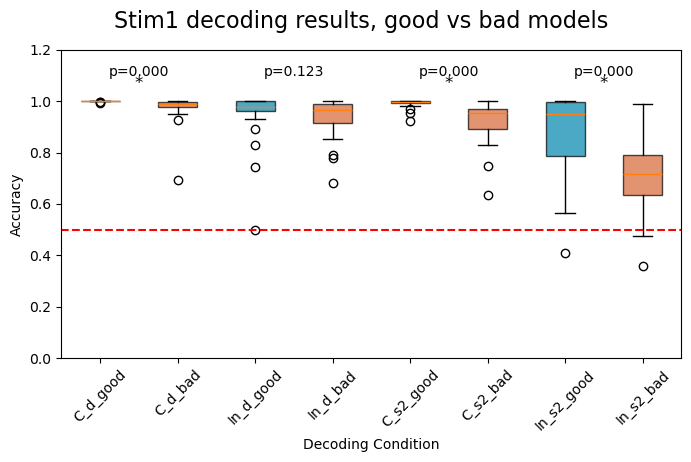

In [33]:
# plot boxplot comparing good and bad models
fig, axs = plt.subplots(1, 1, figsize=(8, 4))
fig.suptitle(f'Stim1 decoding results, good vs bad models', fontsize=16)
bp = axs.boxplot([decoding_results_good['acc_corr_delay2'].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan), decoding_results_bad['acc_corr_delay2'].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan), 
                  decoding_results_good['acc_incorr_delay2'].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan), decoding_results_bad['acc_incorr_delay2'].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan), 
                  decoding_results_good['acc_corr_stim2'].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan), decoding_results_bad['acc_corr_stim2'].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan), 
                  decoding_results_good['acc_incorr_stim2'].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan), decoding_results_bad['acc_incorr_stim2'].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan)], 
                 patch_artist=True)
for k, box in enumerate(bp['boxes']):
    if k % 2 == 0:
        box.set_facecolor('#0085AD')  # Set the face color of the box for good models
    else:
        box.set_facecolor('#D76735')  # Set the face color of the box for bad models
    box.set_edgecolor('black')  # Optionally set edge color
    box.set_alpha(0.7)  # Set transparency (optional)
# Add significance stars and p-values
axs.text(1.5, 1.05, '*', fontsize=12, color='black', ha='center')
axs.text(1.5, 1.1, f'p={scipy.stats.mannwhitneyu(decoding_results_good["acc_corr_delay2"].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan), decoding_results_bad["acc_corr_delay2"].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan))[1]:.3f}', 
         fontsize=10, color='black', ha='center')
# axs.text(3.5, 1.05, '*', fontsize=12, color='black', ha='center')
axs.text(3.5, 1.1, f'p={scipy.stats.mannwhitneyu(decoding_results_good["acc_incorr_delay2"].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan), decoding_results_bad["acc_incorr_delay2"].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan))[1]:.3f}', 
         fontsize=10, color='black', ha='center')
axs.text(5.5, 1.05, '*', fontsize=12, color='black', ha='center')
axs.text(5.5, 1.1, f'p={scipy.stats.mannwhitneyu(decoding_results_good["acc_corr_stim2"].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan), decoding_results_bad["acc_corr_stim2"].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan))[1]:.3f}', 
         fontsize=10, color='black', ha='center')
axs.text(7.5, 1.05, '*', fontsize=12, color='black', ha='center')
axs.text(7.5, 1.1, f'p={scipy.stats.mannwhitneyu(decoding_results_good["acc_incorr_stim2"].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan), decoding_results_bad["acc_incorr_stim2"].apply(lambda x: np.nanmean(x) if len(x) > 0 else np.nan))[1]:.3f}', 
         fontsize=10, color='black', ha='center')
axs.axhline(y=0.5, color='r', linestyle='--')
axs.set_ylabel('Accuracy')
axs.set_ylim(0, 1.2)
axs.set_xticks([1, 2, 3, 4, 5, 6, 7, 8])
axs.set_xticklabels(['C_d_good', 'C_d_bad', 'In_d_good', 'In_d_bad', 'C_s2_good', 'C_s2_bad', 'In_s2_good', 'In_s2_bad'], rotation=45)
axs.set_xlabel('Decoding Condition');

